<a href="https://colab.research.google.com/github/VARUN-KUMAR13/test/blob/main/Task_13_GraphX_with_GraphFrames_and_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


PageRank:


/usr/local/lib/python3.12/dist-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


+---+-------------------+
| id|           pagerank|
+---+-------------------+
|  g|0.17073170731707318|
|  f|0.34304852959857723|
|  e|0.40545134654471543|
|  d|0.34304852959857723|
|  c| 2.7339209603658534|
|  b|  2.514646227134146|
|  a|0.48915269944105694|
+---+-------------------+

Connected Components:
+---+------------+
| id|   component|
+---+------------+
|  a|412316860416|
|  b|412316860416|
|  c|412316860416|
|  d|412316860416|
|  e|412316860416|
|  f|412316860416|
|  g|146028888064|
+---+------------+

Triangle Count:
+---+-----+
| id|count|
+---+-----+
|  c|    0|
|  b|    0|
|  a|    1|
|  g|    0|
|  f|    0|
|  e|    1|
|  d|    1|
+---+-----+



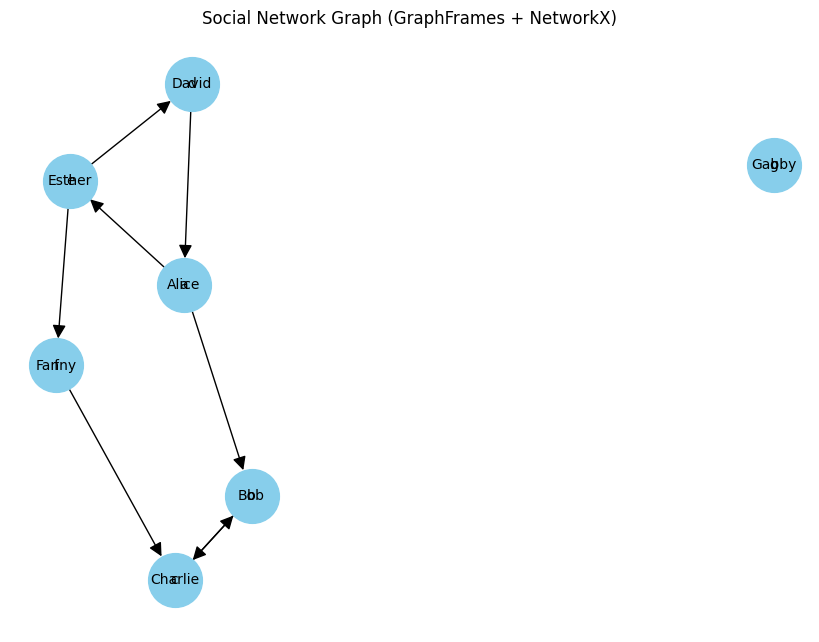

In [ ]:
!pip install pyspark graphframes

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("GraphFramesDemo") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.2-s_2.12") \
    .getOrCreate()

from graphframes import GraphFrame

#from graphframes import GraphFrame

# --- Step 3: Build GraphFrames graph ---
vertices = spark.createDataFrame([
    ("a", "Alice", 34),
    ("b", "Bob", 36),
    ("c", "Charlie", 30),
    ("d", "David", 29),
    ("e", "Esther", 32),
    ("f", "Fanny", 36),
    ("g", "Gabby", 60)
], ["id", "name", "age"])

edges = spark.createDataFrame([
    ("a", "b", "follows"),
    ("b", "c", "follows"),
    ("c", "b", "follows"),
    ("f", "c", "follows"),
    ("e", "f", "follows"),
    ("e", "d", "follows"),
    ("d", "a", "follows"),
    ("a", "e", "follows")
], ["src", "dst", "relationship"])

g = GraphFrame(vertices, edges)

# --- Step 4: Run algorithms ---
print("PageRank:")
g.pageRank(resetProbability=0.15, maxIter=5).vertices.select("id","pagerank").show()

sc = spark.sparkContext
sc.setCheckpointDir("/content/graphframes-checkpoints")
print("Connected Components:")
g.connectedComponents().select("id","component").show()

print("Triangle Count:")
g.triangleCount().select("id","count").show()

# --- Step 5: Visualize with NetworkX ---
import networkx as nx
import matplotlib.pyplot as plt

# Convert Spark DataFrames to Pandas
v_pd = vertices.toPandas()
e_pd = edges.toPandas()

# Build NetworkX graph
G = nx.DiGraph()
for idx, row in v_pd.iterrows():
    G.add_node(row["id"], label=row["name"], age=row["age"])
for idx, row in e_pd.iterrows():
    G.add_edge(row["src"], row["dst"], rel=row["relationship"])

# Draw graph
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=1500, node_color="skyblue", arrowsize=20, font_size=10)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in G.nodes}, font_size=10)
plt.title("Social Network Graph (GraphFrames + NetworkX)")
plt.show()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


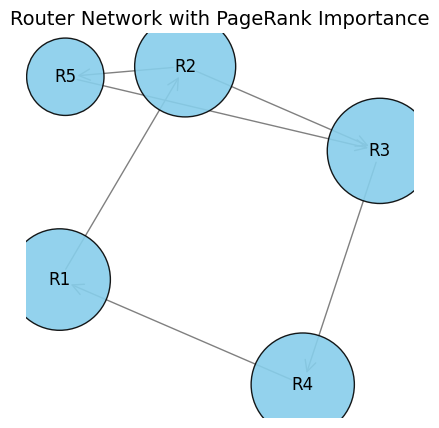

In [ ]:
from pyspark.sql import SparkSession
from graphframes import GraphFrame
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Create Spark Session
# -----------------------------
spark = SparkSession.builder \
    .appName("Router Network Visualization") \
    .getOrCreate()

# -----------------------------
# Step 2: Define Vertices (Routers)
# -----------------------------
routers = spark.createDataFrame([
    ("R1", "Router-1"),
    ("R2", "Router-2"),
    ("R3", "Router-3"),
    ("R4", "Router-4"),
    ("R5", "Router-5")
], ["id", "name"])

# -----------------------------
# Step 3: Define Edges (Connections)
# -----------------------------
connections = spark.createDataFrame([
    ("R1", "R2", "link"),
    ("R2", "R3", "link"),
    ("R3", "R4", "link"),
    ("R4", "R1", "link"),
    ("R2", "R5", "link"),
    ("R5", "R3", "link")
], ["src", "dst", "type"])

# -----------------------------
# Step 4: Build GraphFrame
# -----------------------------
network = GraphFrame(routers, connections)

# -----------------------------
# Step 5: Run PageRank
# -----------------------------
ranks = network.pageRank(resetProbability=0.15, maxIter=10)
pagerank_df = ranks.vertices.select("id", "pagerank").toPandas()

# -----------------------------
# Step 6: Convert to NetworkX
# -----------------------------
v = network.vertices.toPandas()
e = network.edges.toPandas()

G = nx.DiGraph()
for index, row in v.iterrows():
    pr = pagerank_df[pagerank_df["id"] == row["id"]]["pagerank"].values[0]
    G.add_node(row["id"], label=row["name"], pagerank=pr)

for index, row in e.iterrows():
    G.add_edge(row["src"], row["dst"], label=row["type"])

# -----------------------------
# Step 7: Visualize Graph
# -----------------------------
plt.figure(figsize=(5,5))
pos = nx.spring_layout(G, seed=42)

# Node sizes based on PageRank (scaled for visibility)
sizes = [5000 * G.nodes[n]["pagerank"] for n in G.nodes()]

# Draw nodes with PageRank-based size
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=sizes, alpha=0.9, edgecolors="black")

# Draw directed edges
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowstyle="->", arrowsize=20)

# Draw labels (router IDs)
nx.draw_networkx_labels(G, pos, font_size=12, font_color="black")

# Title
plt.title("Router Network with PageRank Importance", fontsize=14)
plt.axis("off")
plt.show()
